# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [ ]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [ ]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [ ]:
from astropy.time import Time
from zoneinfo import ZoneInfo
IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")
now = Time.now()
print("UTC :", now.utc.isot)
iitk_time = now.to_datetime(timezone=IITK_TIMEZONE)
print(
    "IST :",
    iitk_time.strftime("%Y-%m-%d %H:%M:%S IST")
)

UTC : 2026-09-06T13:24:16.483
IST : 2026-09-06 18:54:16 IST


Since IST = UST + 5hr 30 mins.While calling Time.now() ,we are talking about the same instant.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [ ]:
from astropy import units as u
height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz


height_km = height.to(u.km)

frequency_THz = frequency.to(
    u.THz,
    equivalencies=u.spectral()
)

uncertainty_arcsec = uncertainty.to(u.arcsec)

cadence_hours = cadence.to(u.hour)

wavelength_cm = frequency.to(
    u.cm,
    equivalencies=u.spectral()
)

# Print original and converted values
print("GTC height       :", height, "->", height_km)
print("Wavelength       :", wavelength, "->", wavelength_cm)
print("Coordinate error  :", uncertainty, "->", uncertainty_arcsec)
print("Cadence          :", cadence, "->", cadence_hours)
print("Radio frequency  :", frequency, "->", frequency_THz)


GTC height       : 2396.0 m -> 2.396 km
Wavelength       : 600.0 nm -> 21.413747 cm
Coordinate error  : 5.0 mas -> 0.005 arcsec
Cadence          : 10.0 min -> 0.16666666666666666 h
Radio frequency  : 1.4 GHz -> 0.0014 THz


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [ ]:
planning_start = Time(START_UTC, scale="utc")

print("UTC :", planning_start.utc.isot)
print("JD  :", planning_start.jd)
print("MJD :", planning_start.mjd)
print("IST :", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour

print("\nAfter adding 2.25 hours:")
print("UTC :", later.utc.isot)
print("IST :", format_iitk(later))

ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
round_trip = Time(ist_datetime)

difference = abs((round_trip - planning_start).to_value(u.us))

print("\nRound-trip difference =", difference, "microseconds")
print("Less than one microsecond:", difference < 1.0)

UTC : 2026-08-30T12:00:00.000
JD  : 2461283.0
MJD : 61282.5
IST : 2026-08-30 17:30:00 IST

After adding 2.25 hours:
UTC : 2026-08-30T14:15:00.000
IST : 2026-08-30 19:45:00 IST

Round-trip difference = 0.0 microseconds
Less than one microsecond: True


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [ ]:
ra = Angle(FRB_RA_J2000)
dec = Angle(FRB_DEC_J2000)

frb_icrs = SkyCoord(
    ra=ra,
    dec=dec,
    frame="icrs"
)

print("RA decimal degrees :", frb_icrs.ra.deg)
print("Dec decimal degrees:", frb_icrs.dec.deg)

print("RA sexagesimal     :", frb_icrs.ra.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    precision=4
))

print("Dec sexagesimal    :", frb_icrs.dec.to_string(
    unit=u.deg,
    sep=":",
    pad=True,
    precision=4,
    alwayssign=True
))

assert abs(frb_icrs.ra.deg - 347.2704120833) < 1e-8
assert abs(frb_icrs.dec.deg - 48.7066410556) < 1e-8

RA decimal degrees : 347.27041208333327
Dec decimal degrees: 48.70664105555556
RA sexagesimal     : 23:09:04.8989
Dec sexagesimal    : +48:42:23.9078


Right Ascension is commonly expressed in hours because the celestial sphere is connected naturally to Earth's rotation:

$$ 24~h = 360^\circ. $$
=> $$ 1~h=15^\circ. $$

Declination is somewhat similsr to terrestrial latitude and that is why it is expressed directly in degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [ ]:
frb_galactic = frb_icrs.galactic

print("Galactic longitude l =", frb_galactic.l.deg, "deg")
print("Galactic latitude  b =", frb_galactic.b.deg, "deg")

frb_back = frb_galactic.icrs

separation = frb_icrs.separation(frb_back)

print(
    "Round-trip separation =",
    separation.to(u.microarcsecond)
)

Galactic longitude l = 106.06496077332801 deg
Galactic latitude  b = -10.784176285402493 deg
Round-trip separation = 0.000310733 uarcsec


Galactic coordinates are used for the Milky Way:

\(l\) = Galactic longitude
\(b\) = Galactic latitude

The transformation will be

$$ ICRS\rightarrow Galactic\rightarrow ICRS $$

it means it will come back tothe initial position.

Any extremely small residual is beccause of finite numerical precision and coordinate transformation round-off, not because of an actual movement of the FRB.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [ ]:
frb_ecliptic = frb_icrs.transform_to(
    BarycentricTrueEcliptic(equinox=Time("J2000"))
)

print("Ecliptic longitude lambda =",
      frb_ecliptic.lon.deg, "deg")

print("Ecliptic latitude beta =",
      frb_ecliptic.lat.deg, "deg")
assert 0 <= frb_ecliptic.lon.deg < 360
assert -90 <= frb_ecliptic.lat.deg <= 90

frb_ecliptic_back = frb_ecliptic.transform_to("icrs")

separation = frb_icrs.separation(frb_ecliptic_back)

print(
    "Round-trip separation =",
    separation.to(u.microarcsecond)
)

Ecliptic longitude lambda = 14.411187650340095 deg
Ecliptic latitude beta = 48.34695843744783 deg
Round-trip separation = 0 uarcsec


The ecliptic plane is the plane of Earth's orbit around the Sun.

The ecliptic latitude $\beta$ measures the angular distance of the source above or below that plane.

Therefore:

$\beta=0^\circ$ : source lies on the ecliptic.

$\beta$ large:  source is far from the ecliptic

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [ ]:
earlier_position = SkyCoord(
    ra=Angle(EARLIER_POSITION_RA),
    dec=Angle(EARLIER_POSITION_DEC),
    frame="icrs"
)

ra1 = frb_icrs.ra.to_value(u.rad)
dec1 = frb_icrs.dec.to_value(u.rad)

ra2 = earlier_position.ra.to_value(u.rad)
dec2 = earlier_position.dec.to_value(u.rad)

cos_theta = (
    np.sin(dec1) * np.sin(dec2)
    + np.cos(dec1) * np.cos(dec2) * np.cos(ra2 - ra1)
)


cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta = np.arccos(cos_theta)

manual_separation = theta * u.rad

print(
    "Manual separation =",
    manual_separation.to(u.arcsec)
)

print(
    "Manual separation =",
    manual_separation.to(u.mas)
)

astropy_separation = frb_icrs.separation(earlier_position)

print(
    "Astropy separation =",
    astropy_separation.to(u.arcsec)
)

difference = abs(
    manual_separation - astropy_separation
)

print(
    "Difference =",
    difference.to(u.arcsec)
)

assert difference.to_value(u.arcsec) < 2.5e-6

Manual separation = 1.4922374490540065 arcsec
Manual separation = 1492.2374490540062 mas
Astropy separation = 1.49224 arcsec
Difference = 2.27715e-06 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [ ]:
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

print("Longitude:", gtc_location.lon)
print("Latitude :", gtc_location.lat)
print("Height   :", gtc_location.height)

Longitude: -17d53m20.4s
Latitude : 28d45m28.8s
Height   : 2395.9999999997463 m


The negative longitude means that GTC lies west of the Greenwich meridian.

Therefore,

$$ \lambda=-17.889^\circ $$

means $$\ 17.889^\circ$$ west longitude.

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [ ]:
t = Time("2026-08-31T00:00:00", scale="utc")

lst = t.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC :", format_utc(t))
print("IST :", format_iitk(t))
print("LST :", lst.to_string(unit=u.hourangle, sep=":"))
print("H   :", hour_angle.to_string(unit=u.hourangle, sep=":"))

if hour_angle < 0 * u.hourangle:
    print("The target is east of the meridian.")
elif hour_angle > 0 * u.hourangle:
    print("The target is west of the meridian.")
else:
    print("The target is transiting.")

UTC : 2026-08-31 00:00:00 UTC
IST : 2026-08-31 05:30:00 IST
LST : 21:25:12.20821623
H   : -1:43:52.69068377
The target is east of the meridian.


The hour angle is
 H=LST-RA

Therefore:

\(H<0\): source is east of the meridian

\(H=0\): source is on the meridian / transiting

\(H>0\): source is west of the meridian

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [ ]:
lst_all = times.sidereal_time(
    kind="apparent",
    longitude=gtc_location.lon
)

hour_angles = (
    lst_all - frb_icrs.ra
).wrap_at(12 * u.hourangle)

abs_hour_angles = np.abs(
    hour_angles.to_value(u.hourangle)
)

transit_index = np.argmin(abs_hour_angles)

transit_time = times[transit_index]
transit_lst = lst_all[transit_index]
transit_H = hour_angles[transit_index]

print("Sample index :", transit_index)
print("UTC          :", format_utc(transit_time))
print("IST          :", format_iitk(transit_time))
print("LST          :", transit_lst.to_string(
    unit=u.hourangle,
    sep=":"
))
print("Hour angle   :", transit_H.to_string(
    unit=u.hourangle,
    sep=":"
))

Sample index : 82
UTC          : 2026-08-31 01:40:00 UTC
IST          : 2026-08-31 07:10:00 IST
LST          : 23:05:28.63507714
Hour angle   : -0:03:36.26382286


The grid has a cadence of

$$ 10~{\rm min}. $$

Therefore, the actual \(H=0\) instant can occur between two samples.

We only select

$$ \min |H_i| $$

among the available samples.

Thus this is the nearest sampled transit, not necessarily the exact transit.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [ ]:
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

transit_altitude = (
    90 * u.deg - abs(phi - delta)
)

transit_zenith_distance = (
    90 * u.deg - transit_altitude
)

print("Analytic transit altitude =",
      transit_altitude)

print("Analytic zenith distance =",
      transit_zenith_distance)

altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)

altitudes = frb_gtc_altaz.alt

max_index = np.argmax(
    altitudes.to_value(u.deg)
)

max_altitude = altitudes[max_index]
max_zenith_distance = 90 * u.deg - max_altitude

print("\nAstropy maximum sampled altitude =",
      max_altitude)

print("Astropy sampled zenith distance =",
      max_zenith_distance)

print("Maximum altitude sample:")
print("UTC :", format_utc(times[max_index]))
print("IST :", format_iitk(times[max_index]))

Analytic transit altitude = 70d03m04.8922s
Analytic zenith distance = 19d56m55.1078s

Astropy maximum sampled altitude = 69d53m02.08616823s
Astropy sampled zenith distance = 20d06m57.91383177s
Maximum altitude sample:
UTC : 2026-08-31 01:40:00 UTC
IST : 2026-08-31 07:10:00 IST


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [ ]:
offset_samples = [-12, 0, 12]

for offset in offset_samples:

    index = transit_index + offset

    t = times[index]
    H = hour_angles[index]

    H_rad = H.to_value(u.rad)
    phi_rad = phi.to_value(u.rad)
    delta_rad = delta.to_value(u.rad)

    sin_h = (
        np.sin(phi_rad) * np.sin(delta_rad)
        + np.cos(phi_rad)
        * np.cos(delta_rad)
        * np.cos(H_rad)
    )

    sin_h = np.clip(sin_h, -1, 1)

    h_manual = np.arcsin(sin_h) * u.rad

    h_astropy = frb_gtc_altaz.alt[index]

    difference = (
        h_manual - h_astropy
    ).to(u.arcsec)

    print("\nUTC       :", format_utc(t))
    print("IST       :", format_iitk(t))
    print("Hour angle:", H.to_string(
        unit=u.hourangle,
        sep=":"
    ))
    print("Calculated altitude:", h_manual.to(u.deg))
    print("Astropy altitude   :", h_astropy.to(u.deg))
    print("Difference         :", difference)


UTC       : 2026-08-30 23:40:00 UTC
IST       : 2026-08-31 05:10:00 IST
Hour angle: -2:03:55.97605409
Calculated altitude: 59.031948665002126 deg
Astropy altitude   : 58d46m53.67263948s
Difference         : 901.343 arcsec

UTC       : 2026-08-31 01:40:00 UTC
IST       : 2026-08-31 07:10:00 IST
Hour angle: -0:03:36.26382286
Calculated altitude: 70.039347468167 deg
Astropy altitude   : 69d53m02.08616823s
Difference         : 559.565 arcsec

UTC       : 2026-08-31 03:40:00 UTC
IST       : 2026-08-31 09:10:00 IST
Hour angle: 1:56:43.44842115
Calculated altitude: 60.063043754805115 deg
Astropy altitude   : 60d09m45.39530037s
Difference         : -358.438 arcsec


As the source approaches the meridian:

$$ |H|\rightarrow0, $$

so altitude increases.

At transit:

$$ H=0, $$

and altitude reaches its maximum.

After transit:

$$ H>0, $$

and altitude decreases.

Thus the altitude curve is approximately symmetric around transit for this simple geometric relation.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [ ]:
h_min = MIN_TARGET_ALTITUDE_DEG * u.deg

phi_rad = phi.to_value(u.rad)
delta_rad = delta.to_value(u.rad)
hmin_rad = h_min.to_value(u.rad)

cos_H0 = (
    np.sin(hmin_rad)
    - np.sin(phi_rad) * np.sin(delta_rad)
) / (
    np.cos(phi_rad) * np.cos(delta_rad)
)

cos_H0 = np.clip(cos_H0, -1, 1)

H0_rad = np.arccos(cos_H0)
H0_deg = np.degrees(H0_rad)

H0_hours = H0_deg / 15.0

total_hours = 2 * H0_hours

above_20 = (
    frb_gtc_altaz.alt.to_value(u.deg)
    >= MIN_TARGET_ALTITUDE_DEG
)

number_of_samples = np.count_nonzero(above_20)

print("H0 =", H0_deg, "deg")
print("H0 =", H0_hours, "sidereal hours")
print("Total interval =", total_hours, "hours")
print("Samples above 20 deg =", number_of_samples)

H0 = 91.92747700350239 deg
H0 = 6.128498466900159 sidereal hours
Total interval = 12.256996933800318 hours
Samples above 20 deg = 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [ ]:
target_airmass = np.array(frb_gtc_altaz.secz, dtype=float)
target_altitude_deg = frb_gtc_altaz.alt.to_value(u.deg)

for i in range(len(target_airmass)):
    if target_altitude_deg[i] <= 0:
        target_airmass[i] = np.nan

    if not np.isfinite(target_airmass[i]):
        target_airmass[i] = np.nan

    if target_airmass[i] < 1:
        target_airmass[i] = np.nan

best_index = np.nanargmin(target_airmass)

print("Best airmass:")
print("X   :", target_airmass[best_index])
print("UTC :", format_utc(times[best_index]))
print("IST :", format_iitk(times[best_index]))

count = 0

for x in target_airmass:
    if np.isfinite(x) and x >= 1 and x <= 2.5:
        count = count + 1

print("\nNumber of samples with 1 <= X <= 2.5:", count)

Best airmass:
X   : 1.0649653072737555
UTC : 2026-08-31 01:40:00 UTC
IST : 2026-08-31 07:10:00 IST

Number of samples with 1 <= X <= 2.5: 68


For a source below the horizon,

$$ h\leq0^\circ, $$

the simple secant approximation gives an invalid/nonphysical observing geometry.

Therefore, those values should not be interpreted as atmospheric path lengths.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [ ]:
sun = get_sun(times)

with solar_system_ephemeris.set("builtin"):
    moon = get_body("moon", times)

sun_altaz = sun.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

moon_altaz = moon.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

sun_altitude = sun_altaz.alt.to_value(u.deg)
moon_altitude = moon_altaz.alt.to_value(u.deg)

moon_separation = (
    frb_icrs.separation(moon)
    .to_value(u.deg)
)


elongation = (
    sun.separation(moon)
    .to_value(u.rad)
)

illuminated_fraction = (
    1 - np.cos(elongation)
) / 2

moon_airmass = np.asarray(
    moon_altaz.secz,
    dtype=float
)

moon_airmass[
    (moon_altitude <= 0)
    | (~np.isfinite(moon_airmass))
    | (moon_airmass < 1)
    | (moon_airmass > 3)
] = np.nan


labels = np.full(len(times), "Unknown", dtype=object)

finite = (
    np.isfinite(moon_altitude)
    & np.isfinite(moon_separation)
    & np.isfinite(illuminated_fraction)
)

bright = finite & (
    (
        (illuminated_fraction >= 0.70)
        & (moon_altitude > 10)
    )
    |
    (moon_separation <= 45)
)

dark = finite & (
    (moon_altitude < 0)
    |
    (
        (moon_separation >= 90)
        & (illuminated_fraction <= 0.25)
    )
)
labels[bright] = "Bright"

labels[dark] = "Dark"

gray = finite & ~bright & ~dark
labels[gray] = "Gray"


for i in range(len(times)):
    print(
        format_utc(times[i]),
        "| Sun alt =",
        f"{sun_altitude[i]:.2f}",
        "| Moon alt =",
        f"{moon_altitude[i]:.2f}",
        "| Moon X =",
        moon_airmass[i],
        "| separation =",
        f"{moon_separation[i]:.2f}",
        "| f =",
        f"{illuminated_fraction[i]:.3f}",
        "|",
        labels[i]
    )

print("\nMoon label at transit:", labels[transit_index])

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

2026-08-30 12:00:00 UTC | Sun alt = 63.88 | Moon alt = -37.68 | Moon X = nan | separation = 58.35 | f = 0.941 | Dark
2026-08-30 12:10:00 UTC | Sun alt = 65.33 | Moon alt = -39.41 | Moon X = nan | separation = 58.34 | f = 0.940 | Dark
2026-08-30 12:20:00 UTC | Sun alt = 66.65 | Moon alt = -41.09 | Moon X = nan | separation = 58.34 | f = 0.940 | Dark
2026-08-30 12:30:00 UTC | Sun alt = 67.79 | Moon alt = -42.72 | Moon X = nan | separation = 58.34 | f = 0.940 | Dark
2026-08-30 12:40:00 UTC | Sun alt = 68.73 | Moon alt = -44.30 | Moon X = nan | separation = 58.33 | f = 0.939 | Dark
2026-08-30 12:50:00 UTC | Sun alt = 69.44 | Moon alt = -45.81 | Moon X = nan | separation = 58.33 | f = 0.939 | Dark
2026-08-30 13:00:00 UTC | Sun alt = 69.91 | Moon alt = -47.25 | Moon X = nan | separation = 58.33 | f = 0.939 | Dark
2026-08-30 13:10:00 UTC | Sun alt = 70.11 | Moon alt = -48.61 | Moon X = nan | separation = 58.32 | f = 0.938 | Dark
2026-08-30 13:20:00 UTC | Sun alt = 70.02 | Moon alt = -49.89 | 

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [ ]:
def visibility(
    altitude,
    airmass,
    sun_altitude,
    moon_separation
):
    altitude = np.asarray(altitude)
    airmass = np.asarray(airmass)
    sun_altitude = np.asarray(sun_altitude)
    moon_separation = np.asarray(moon_separation)

    if not (
        altitude.ndim == 1
        and airmass.ndim == 1
        and sun_altitude.ndim == 1
        and moon_separation.ndim == 1
    ):
        raise ValueError("All inputs must be one-dimensional arrays.")

    if not (
        len(altitude)
        == len(airmass)
        == len(sun_altitude)
        == len(moon_separation)
    ):
        raise ValueError("All input arrays must have equal length.")

    state = (
        (altitude >= 20.0)
        & (np.isfinite(airmass))
        & (airmass >= 1.0)
        & (airmass <= 2.5)
        & (sun_altitude <= -18.0)
        & (moon_separation >= 30.0)
    )

    return state

altitude_condition = (
    frb_gtc_altaz.alt.to_value(u.deg)
    >= MIN_TARGET_ALTITUDE_DEG
)

airmass_condition = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= MAX_AIRMASS)
)

sun_condition = (
    sun_altitude <= MAX_SUN_ALTITUDE_DEG
)

moon_condition = (
    moon_separation >= MIN_MOON_SEPARATION_DEG
)

preferred_visibility = visibility(
    frb_gtc_altaz.alt.to_value(u.deg),
    target_airmass,
    sun_altitude,
    moon_separation
)

print("Altitude condition count :",
      np.count_nonzero(altitude_condition))

print("Airmass condition count  :",
      np.count_nonzero(airmass_condition))

print("Sun condition count      :",
      np.count_nonzero(sun_condition))

print("Moon condition count     :",
      np.count_nonzero(moon_condition))

print("Combined visibility count:",
      np.count_nonzero(preferred_visibility))

print(
    "Any observable sample:",
    np.any(preferred_visibility)
)

Altitude condition count : 74
Airmass condition count  : 68
Sun condition count      : 51
Moon condition count     : 145
Combined visibility count: 51
Any observable sample: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [ ]:
import warnings
warnings.filterwarnings("ignore")
def evaluate_visibility_at(t):

    frame = AltAz(
        obstime=t,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    target = frb_icrs.transform_to(frame)

    sun_obj = get_sun(t)

    with solar_system_ephemeris.set("builtin"):
        moon_obj = get_body("moon", t)

    sun_obj_altaz = sun_obj.transform_to(frame)
    moon_obj_altaz = moon_obj.transform_to(frame)

    altitude = target.alt.to_value(u.deg)

    airmass = float(target.secz)

    if (
        altitude <= 0
        or not np.isfinite(airmass)
        or airmass < 1
    ):
        airmass = np.nan

    sun_alt = sun_obj_altaz.alt.to_value(u.deg)

    moon_sep = frb_icrs.separation(
        moon_obj
    ).to_value(u.deg)

    alt_pass = altitude >= 20
    airmass_pass = (
        np.isfinite(airmass)
        and 1 <= airmass <= 2.5
    )
    sun_pass = sun_alt <= -18
    moon_pass = moon_sep >= 30

    final = (
        alt_pass
        and airmass_pass
        and sun_pass
        and moon_pass
    )

    print("\nUTC :", format_utc(t))
    print("IST :", format_iitk(t))

    print("Altitude :", altitude, "deg")
    print("Airmass  :", airmass)
    print("Sun alt  :", sun_alt, "deg")
    print("Moon sep :", moon_sep, "deg")

    print("Altitude condition :", alt_pass)
    print("Airmass condition  :", airmass_pass)
    print("Sun condition      :", sun_pass)
    print("Moon condition     :", moon_pass)

    print("FINAL VISIBILITY   :", final)

    return final


print("===== NEAREST TRANSIT =====")
evaluate_visibility_at(transit_time)

print("\n===== 2026-08-31 06:00 UTC =====")
evaluate_visibility_at(
    Time("2026-08-31T06:00:00", scale="utc")
)

===== NEAREST TRANSIT =====

UTC : 2026-08-31 01:40:00 UTC
IST : 2026-08-31 07:10:00 IST
Altitude : 69.8839128245073 deg
Airmass  : 1.0649653072737555
Sun alt  : -51.95592187823629 deg
Moon sep : 58.075262021165756 deg
Altitude condition : True
Airmass condition  : True
Sun condition      : True
Moon condition     : True
FINAL VISIBILITY   : True

===== 2026-08-31 06:00 UTC =====

UTC : 2026-08-31 06:00:00 UTC
IST : 2026-08-31 11:30:00 IST
Altitude : 37.98648660695393 deg
Airmass  : 1.6247597704376868
Sun alt  : -11.282036773583792 deg
Moon sep : 57.990165676920874 deg
Altitude condition : True
Airmass condition  : True
Sun condition      : False
Moon condition     : True
FINAL VISIBILITY   : False


np.False_


Transit only tells us that

$$ H\approx0, $$

which gives maximum altitude.

But our observing criterion requires all four conditions:

$$ h\geq20^\circ, $$ $$ 1\leq X\leq2.5, $$ $$ h_{\rm Sun}\leq-18^\circ, $$

and

$$ \theta_{\rm Moon}\geq30^\circ. $$

This is stated in the assignment.

Therefore, even a source at transit can fail because of daylight, excessive airmass, or Moon proximity.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Observable intervals:

Interval:
UTC : 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
IST : 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333333333333332 hours
Best target airmass: 1.0649653072737555
Midpoint Moon label: Bright


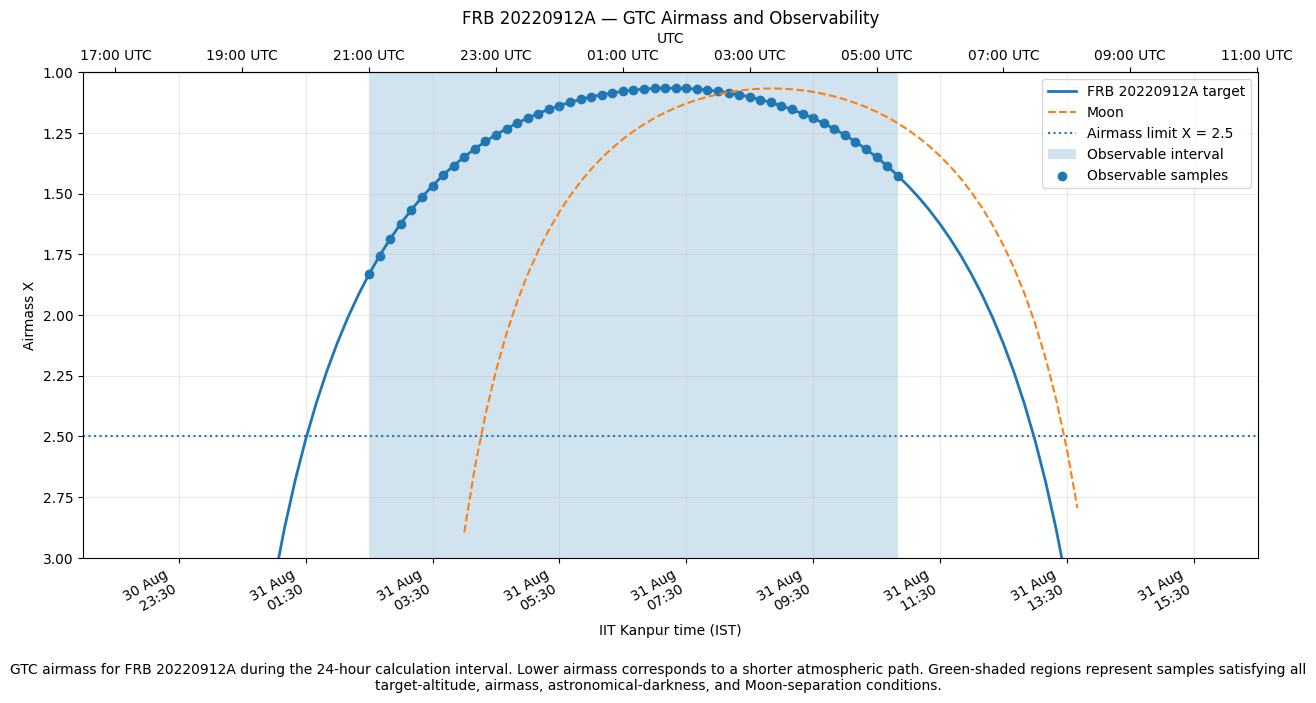

Saved: assignment_outputs/frb_20220912a_gtc_airmass.png


In [ ]:
def stitch_windows(times, visibility_state):

    times = np.asarray(times)
    visibility_state = np.asarray(
        visibility_state,
        dtype=bool
    )

    if times.ndim != 1 or visibility_state.ndim != 1:
        raise ValueError(
            "times and visibility_state must be 1-D."
        )

    if len(times) != len(visibility_state):
        raise ValueError(
            "times and visibility_state must have equal length."
        )

    windows = []

    start = None

    for i, visible in enumerate(visibility_state):

        if visible and start is None:
            start = i

        if (
            start is not None
            and (
                not visible
                or i == len(visibility_state) - 1
            )
        ):

            end = i if (
                visible
                and i == len(visibility_state) - 1
            ) else i - 1

            windows.append(
                (start, end)
            )

            start = None

    return windows

windows = stitch_windows(
    times,
    preferred_visibility
)

print("Observable intervals:")

for start, end in windows:

    start_time = times[start]
    end_time = times[end]

    duration = (
        end_time - start_time
    ).to_value(u.hour)

    best_airmass = np.nanmin(
        target_airmass[start:end + 1]
    )

    midpoint_index = (
        start + end
    ) // 2

    moon_label = labels[midpoint_index]

    print("\nInterval:")
    print("UTC :", format_utc(start_time),
          "to", format_utc(end_time))

    print("IST :", format_iitk(start_time),
          "to", format_iitk(end_time))

    print("Sample-centre duration:",
          duration, "hours")

    print("Best target airmass:",
          best_airmass)

    print("Midpoint Moon label:",
          moon_label)


fig, ax = plt.subplots(figsize=(13, 7))

ax.plot(
    times.to_datetime(),
    target_airmass,
    label="FRB 20220912A target",
    linewidth=2
)


ax.plot(
    times.to_datetime(),
    moon_airmass,
    linestyle="--",
    label="Moon",
    linewidth=1.5
)


ax.axhline(
    2.5,
    linestyle=":",
    linewidth=1.5,
    label="Airmass limit X = 2.5"
)


for start, end in windows:

    ax.axvspan(
        times[start].to_datetime(),
        times[end].to_datetime(),
        alpha=0.2,
        label="Observable interval"
        if start == windows[0][0]
        else None
    )


observable_times = times[preferred_visibility]

observable_airmass = target_airmass[
    preferred_visibility
]

ax.scatter(
    observable_times.to_datetime(),
    observable_airmass,
    marker="o",
    label="Observable samples"
)

ax.set_ylim(3, 1)

ax.set_ylabel("Airmass X")
ax.set_xlabel("IIT Kanpur time (IST)")
ax.set_title(
    "FRB 20220912A — GTC Airmass and Observability"
)

ax.grid(True, alpha=0.25)


ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d %b\n%H:%M",
        tz=IITK_TIMEZONE
    )
)

ax_utc = ax.secondary_xaxis("top")

ax_utc.xaxis.set_major_locator(
    mdates.HourLocator(interval=2)
)

ax_utc.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%H:%M UTC",
        tz=timezone.utc
    )
)

ax_utc.set_xlabel("UTC")


fig.autofmt_xdate()

ax.legend(
    loc="best"
)

caption = (
    "GTC airmass for FRB 20220912A during the 24-hour "
    "calculation interval. Lower airmass corresponds to "
    "a shorter atmospheric path. Green-shaded regions "
    "represent samples satisfying all target-altitude, "
    "airmass, astronomical-darkness, and Moon-separation "
    "conditions."
)

fig.text(
    0.5,
    0.01,
    caption,
    ha="center",
    wrap=True
)

plt.tight_layout(
    rect=[0, 0.06, 1, 1]
)

output_file = (
    OUTPUT_DIR
    / "frb_20220912a_gtc_airmass.png"
)

plt.savefig(
    output_file,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_file)

**Scientific conclusion:** FRB 20220912A is observable from GTC only when all altitude, airmass, astronomical-darkness, and Moon-separation conditions are satisfied simultaneously.


**One limitation of 10 min grid:** The 10-minute sampling may slightly shift the exact start/end times and can miss very short visibility intervals between samples.

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [ ]:
date_start = Time(
    "2026-09-01T00:00:00",
    scale="utc"
)

date_end = Time(
    "2026-09-02T00:00:00",
    scale="utc"
)


date_times = date_start + np.arange(
    145
) * 10 * u.min


date_altaz = frb_icrs.transform_to(
    AltAz(
        obstime=date_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

date_altitude = (
    date_altaz.alt.to_value(u.deg)
)

date_airmass = np.asarray(
    date_altaz.secz,
    dtype=float
)

date_sun = get_sun(date_times)

date_sun_altaz = date_sun.transform_to(
    AltAz(
        obstime=date_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

date_sun_altitude = (
    date_sun_altaz.alt.to_value(u.deg)
)

date_airmass[
    (date_altitude <= 0)
    | (~np.isfinite(date_airmass))
    | (date_airmass < 1)
] = np.nan


date_visibility = (
    (date_altitude > 0)
    & np.isfinite(date_airmass)
    & (date_airmass <= 2.5)
    & (date_sun_altitude <= -18)
)

q19_windows = stitch_windows(
    date_times,
    date_visibility
)

print("Q19 visibility intervals:")

for start, end in q19_windows:

    t1 = date_times[start]
    t2 = date_times[end]

    duration = (
        t2 - t1
    ).to_value(u.hour)

    print("\nUTC:")
    print(format_utc(t1), "to", format_utc(t2))

    print("IST:")
    print(format_iitk(t1), "to", format_iitk(t2))

    print("Duration:",
          duration, "hours")

Q19 visibility intervals:

UTC:
2026-09-01 00:00:00 UTC to 2026-09-01 05:20:00 UTC
IST:
2026-09-01 05:30:00 IST to 2026-09-01 10:50:00 IST
Duration: 5.333333333333333 hours

UTC:
2026-09-01 21:00:00 UTC to 2026-09-02 00:00:00 UTC
IST:
2026-09-02 02:30:00 IST to 2026-09-02 05:30:00 IST
Duration: 3.0 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

First date: 2026-08-30 00:00:00.000
Last date : 2027-08-29 00:00:00.000


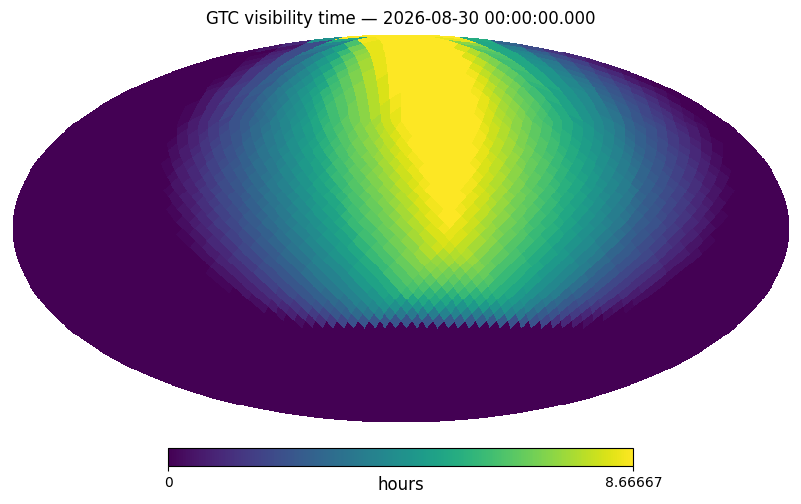

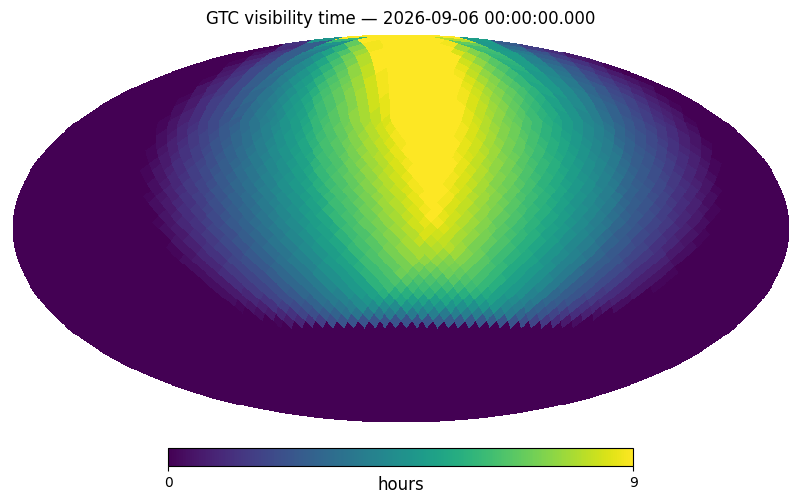

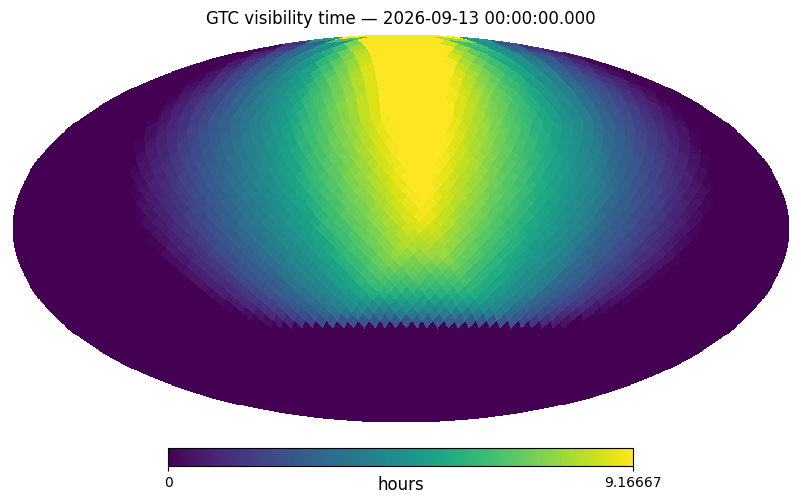

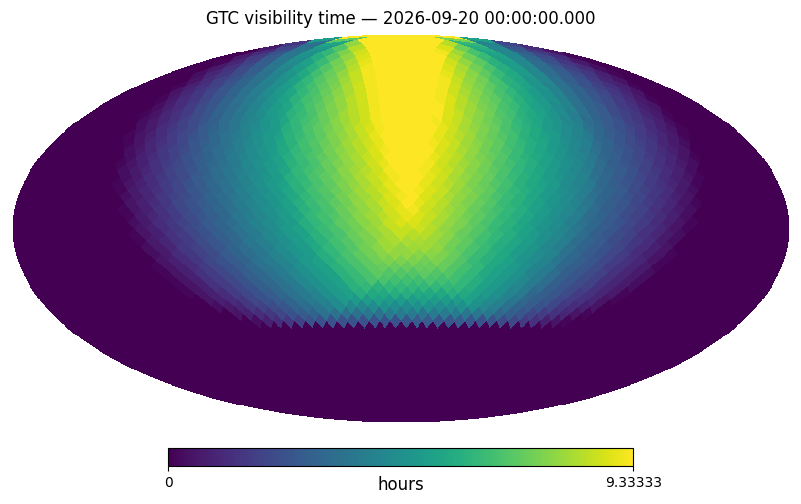

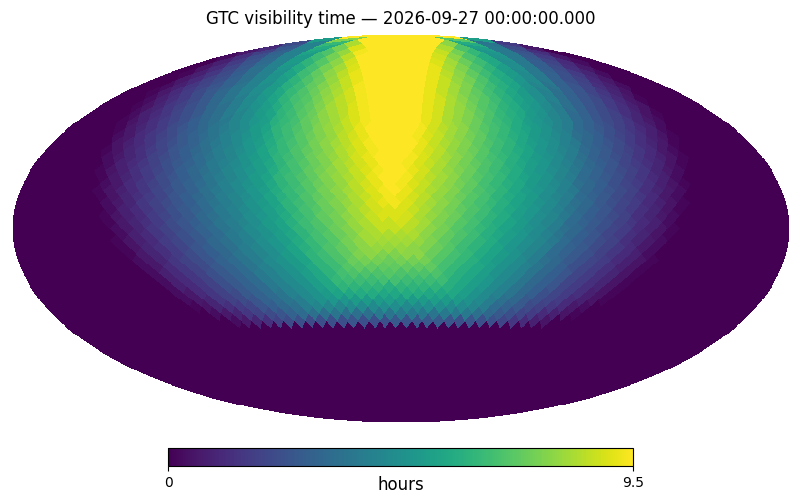

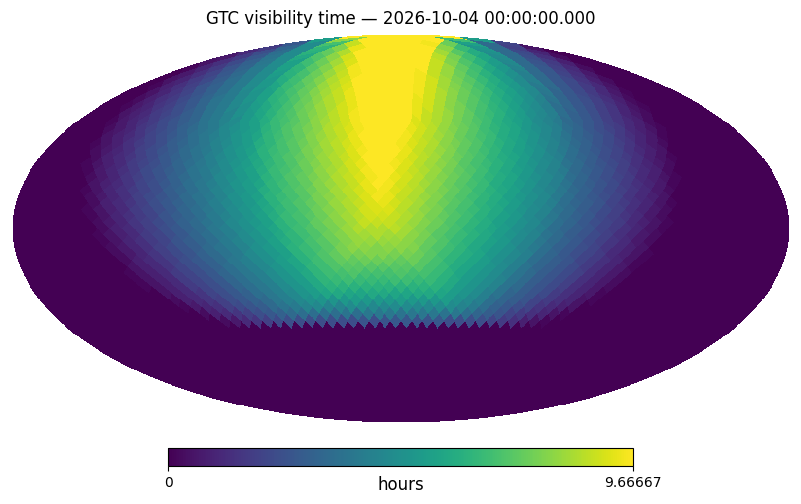

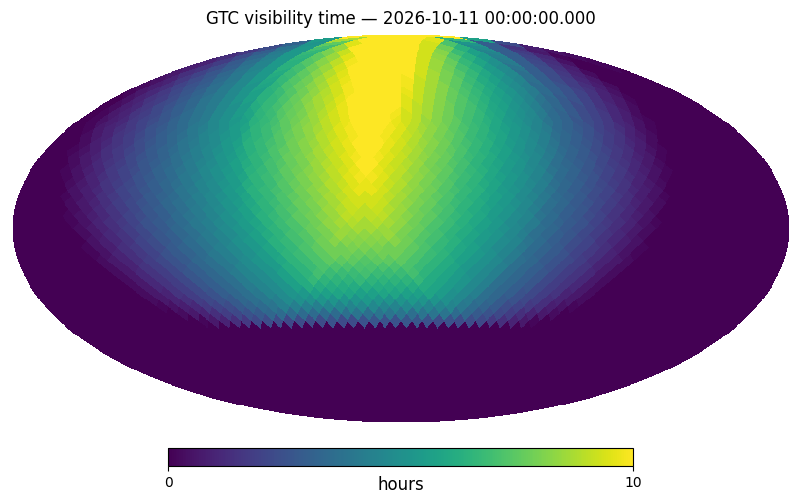

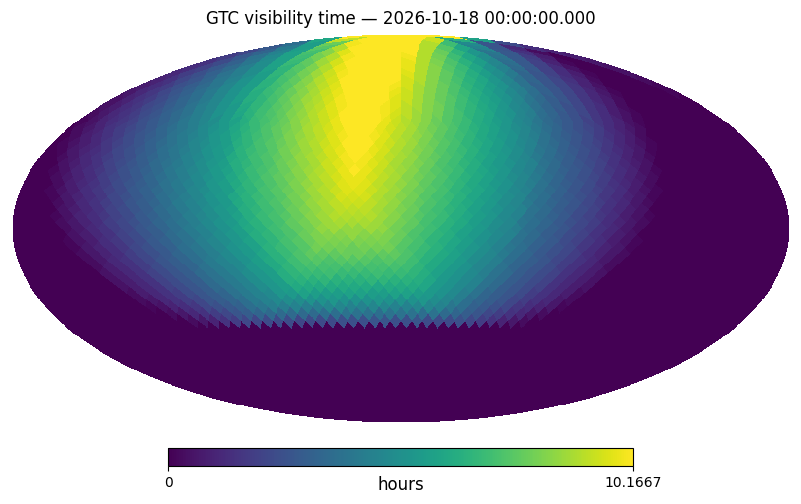

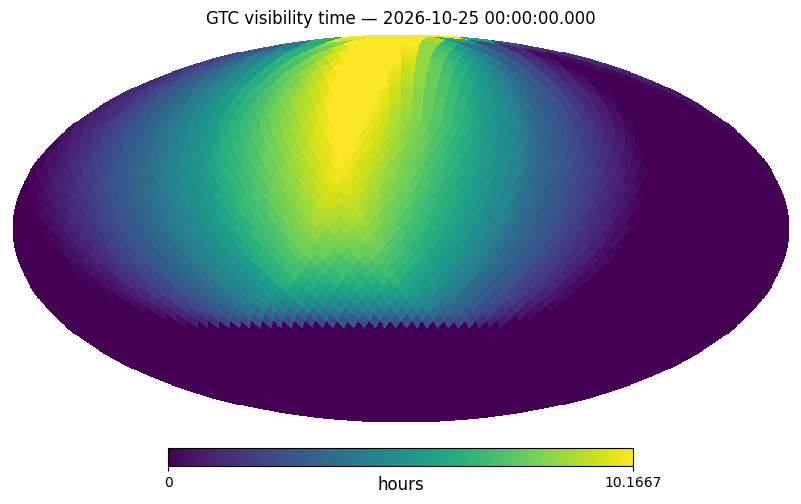

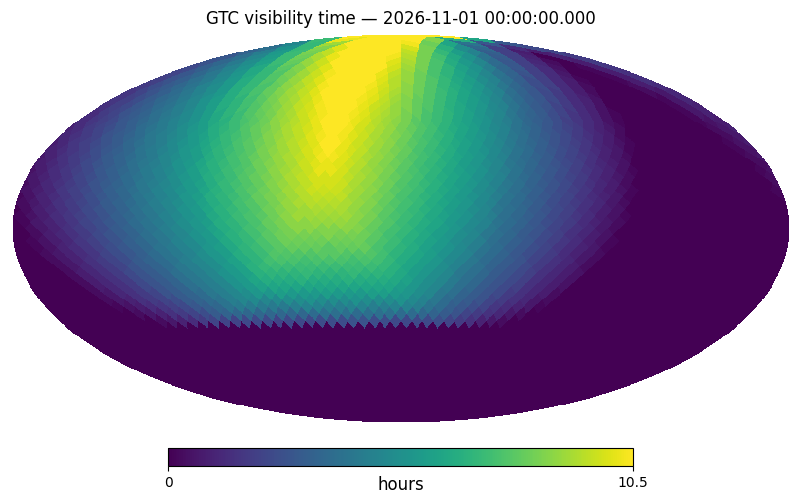

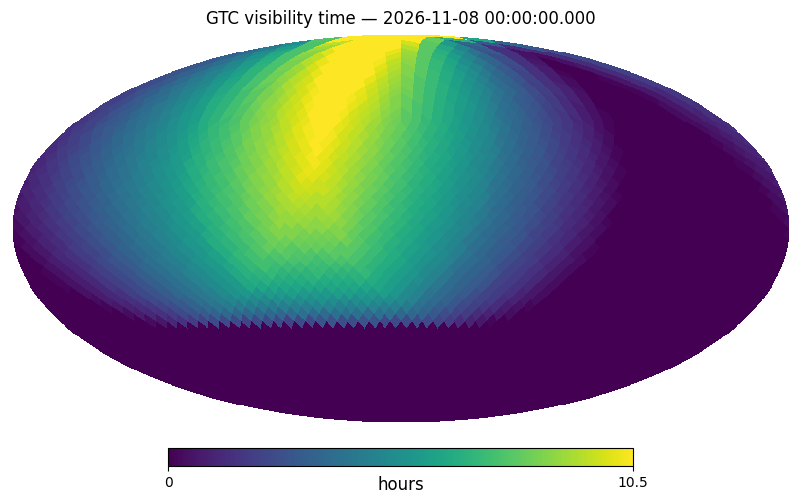

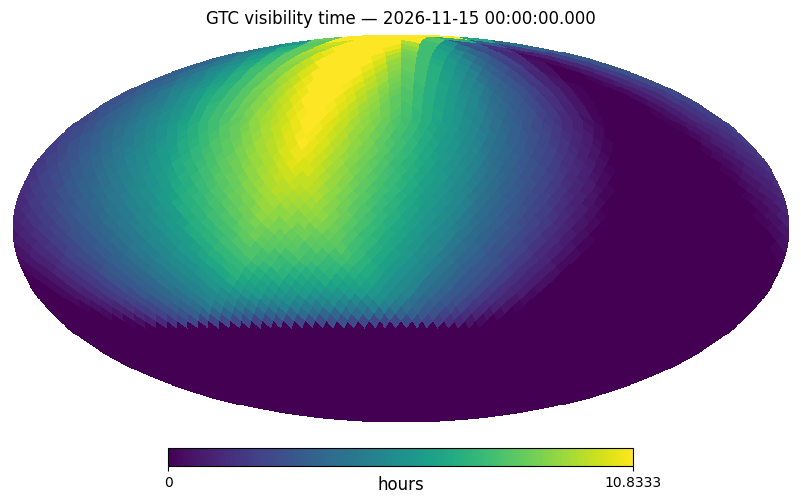

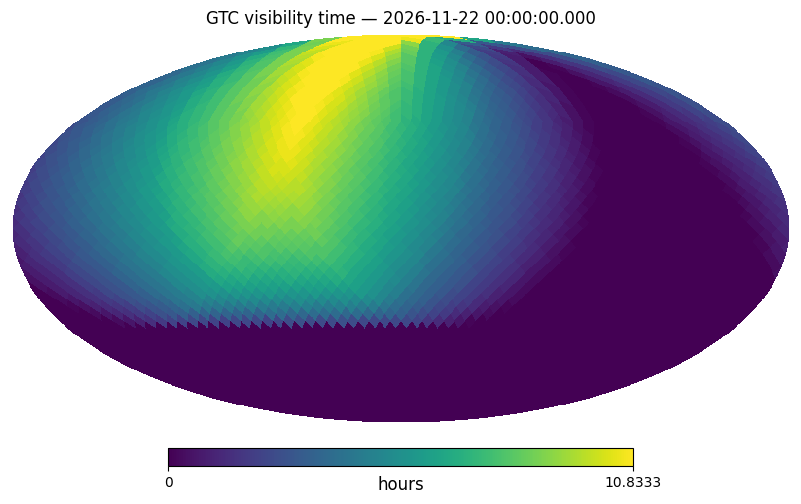

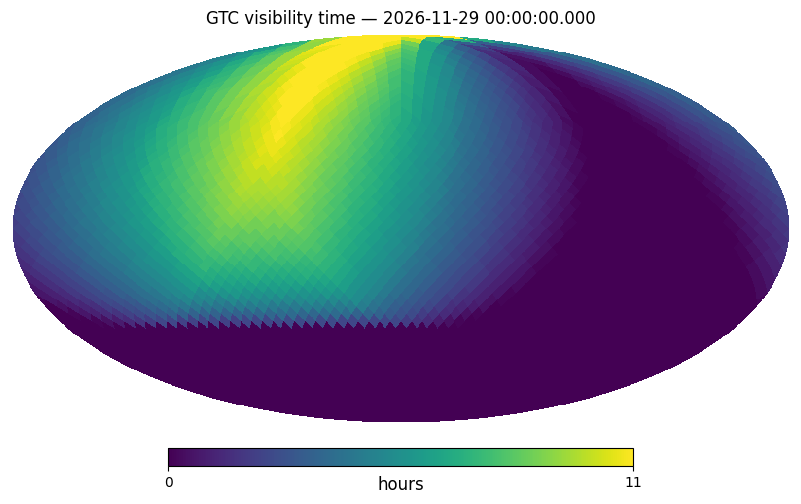

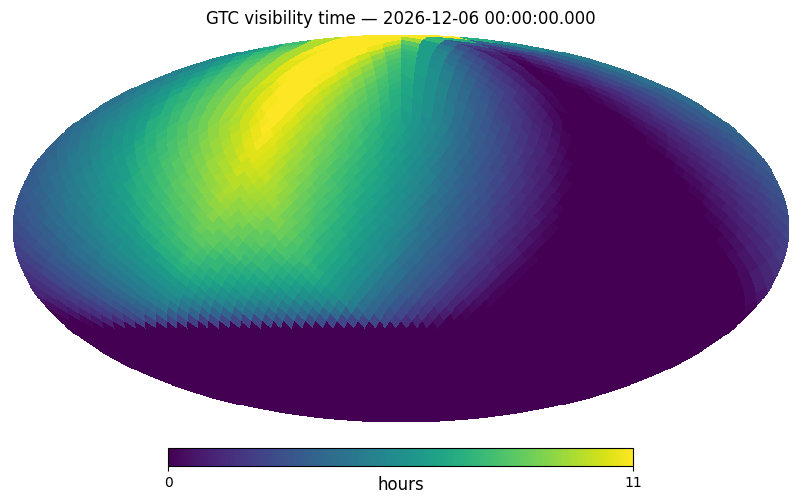

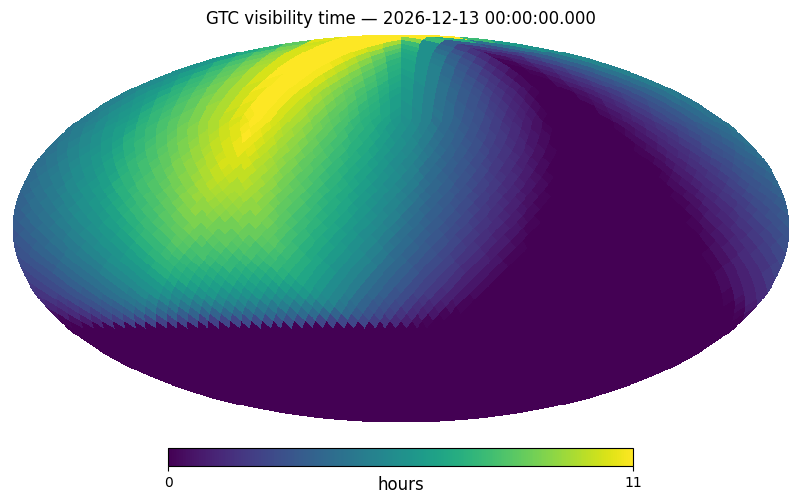

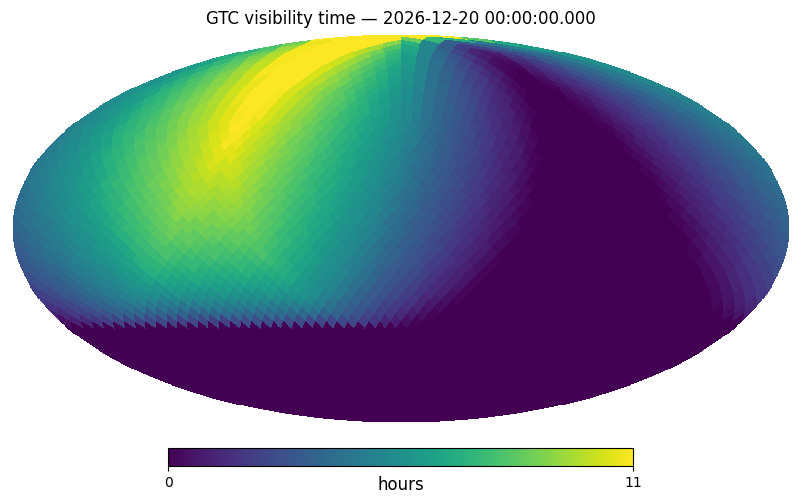

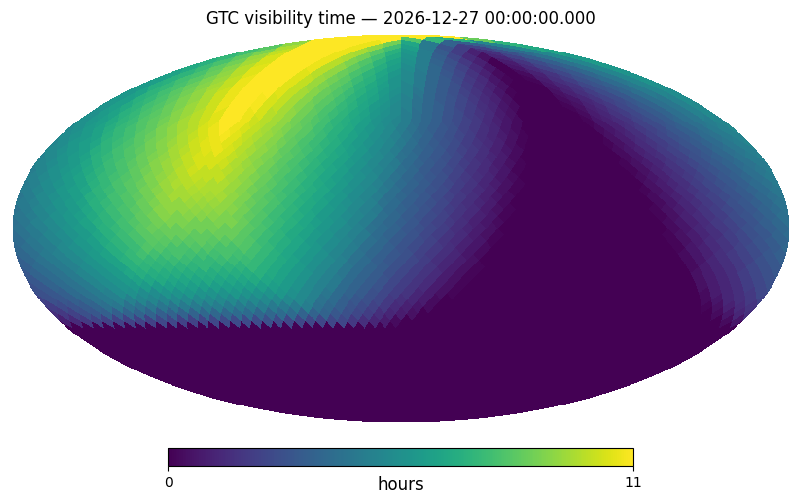

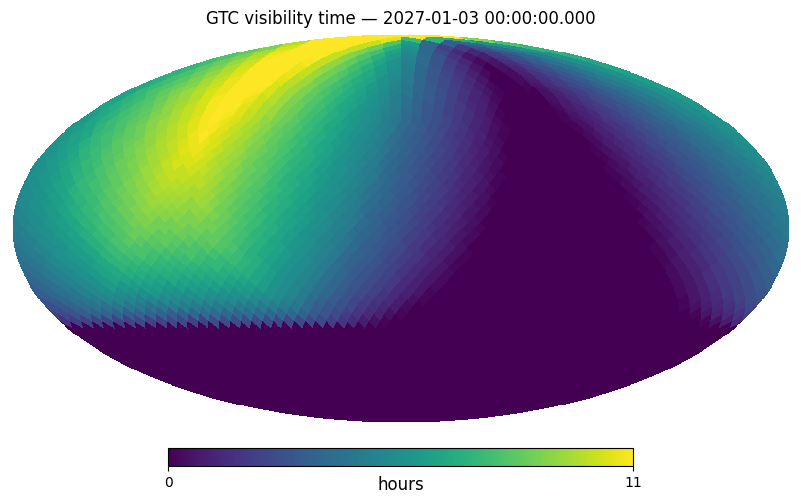

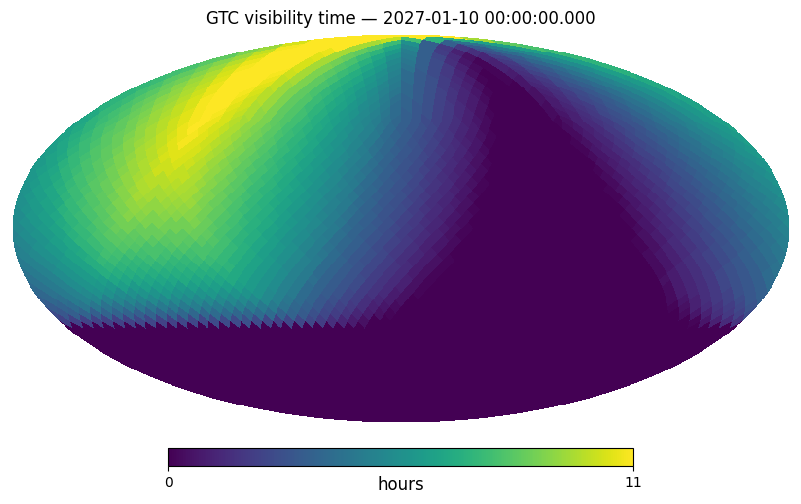

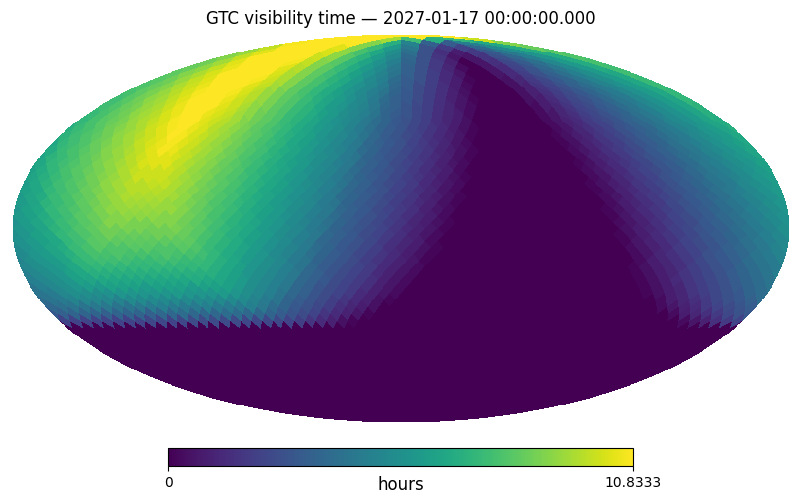

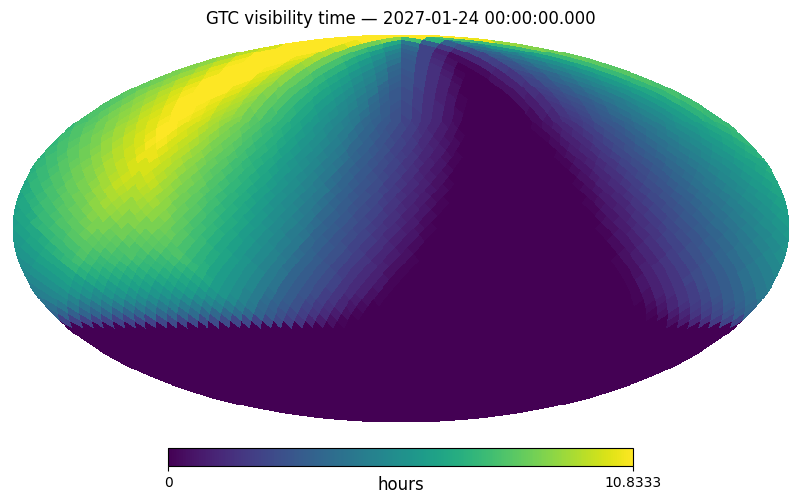

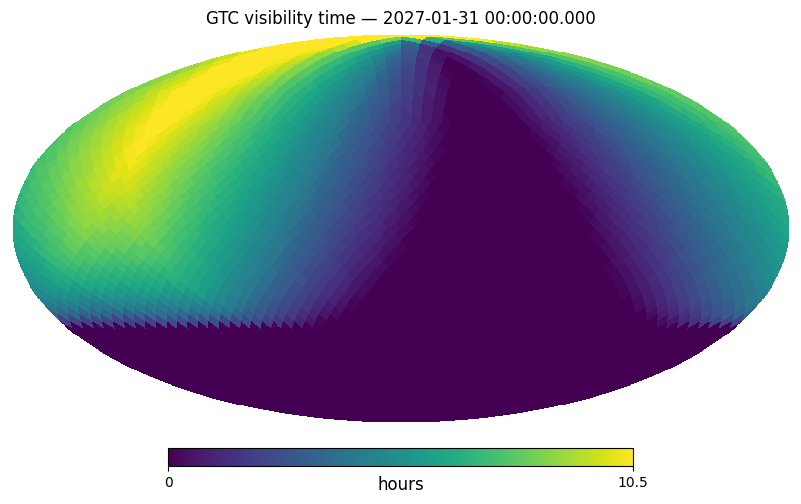

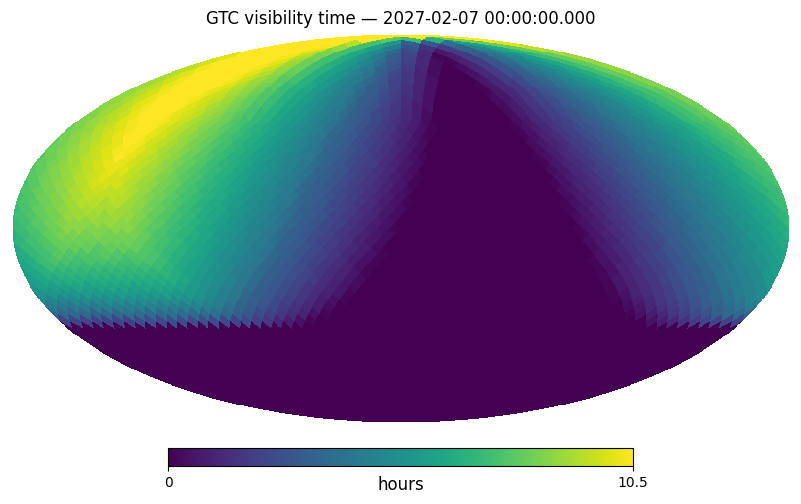

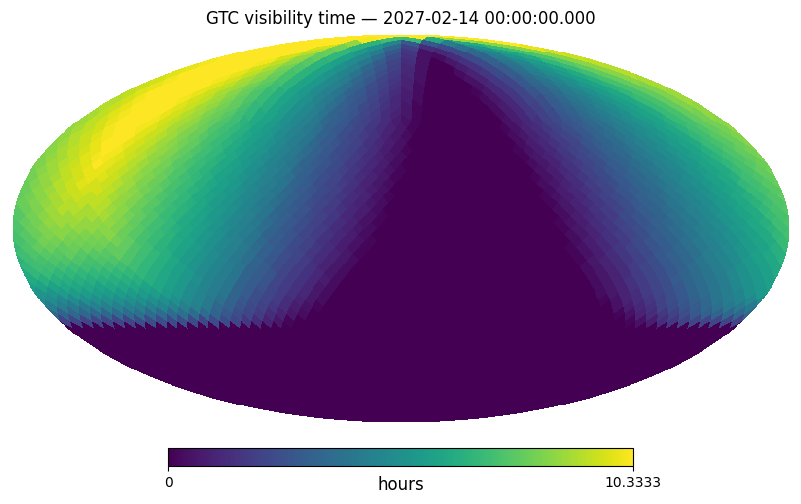

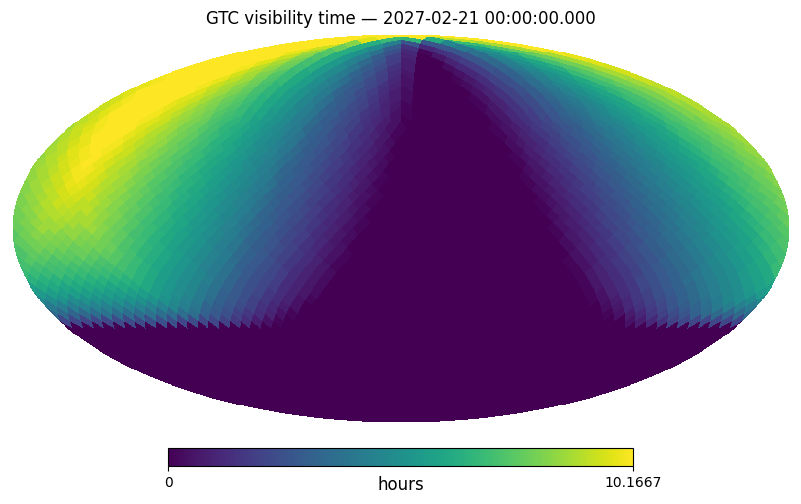

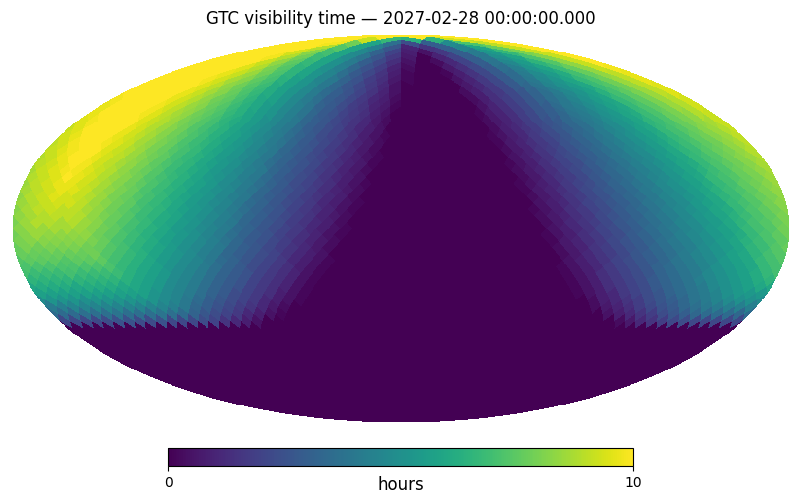

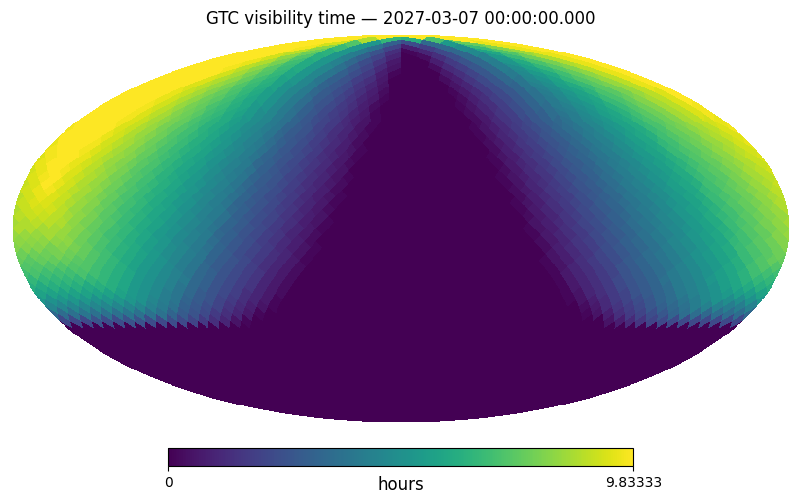

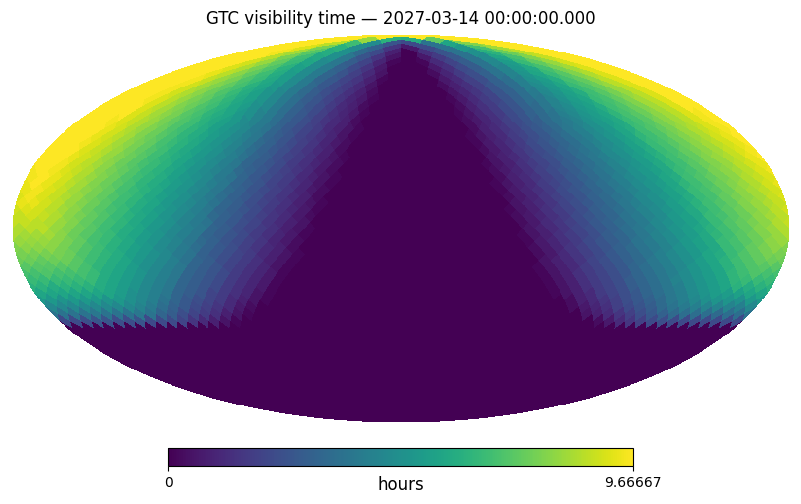

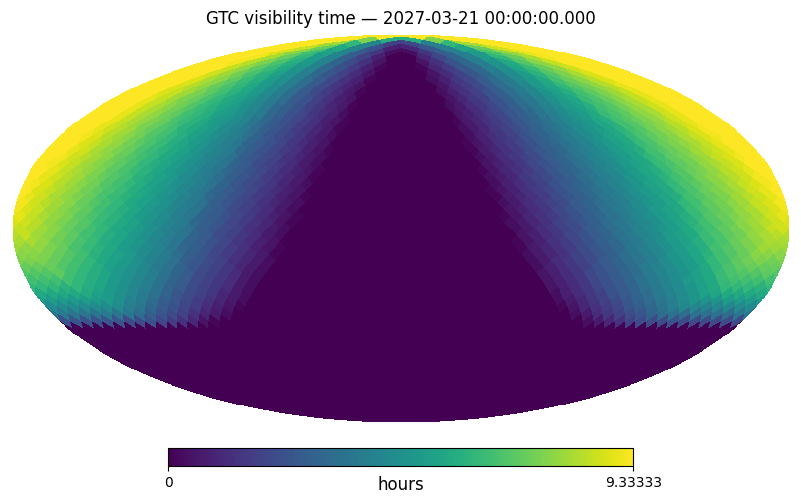

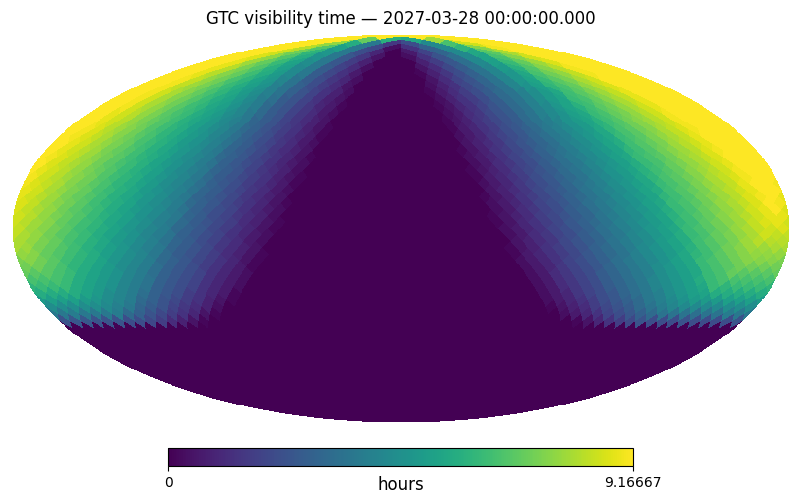

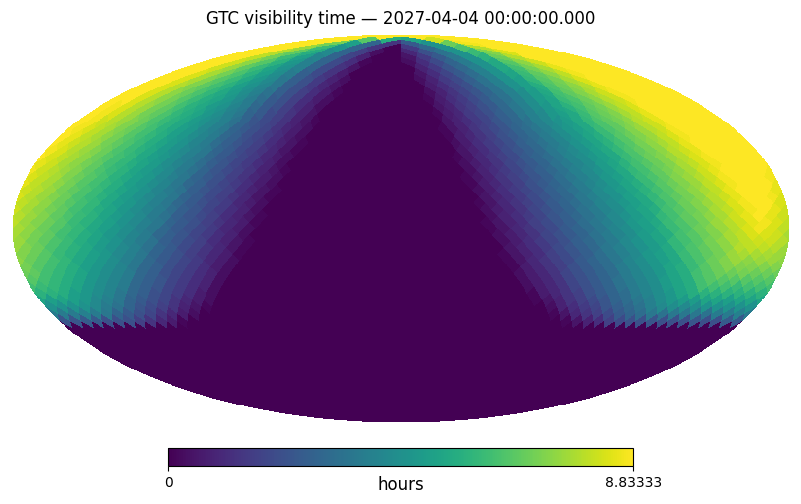

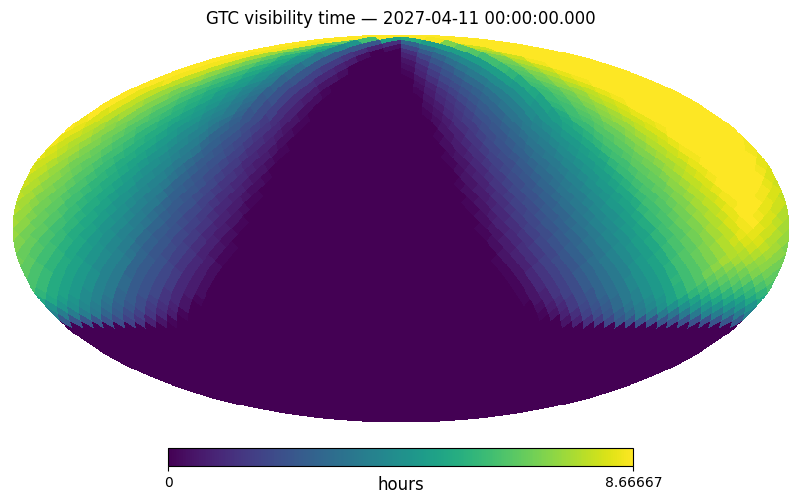

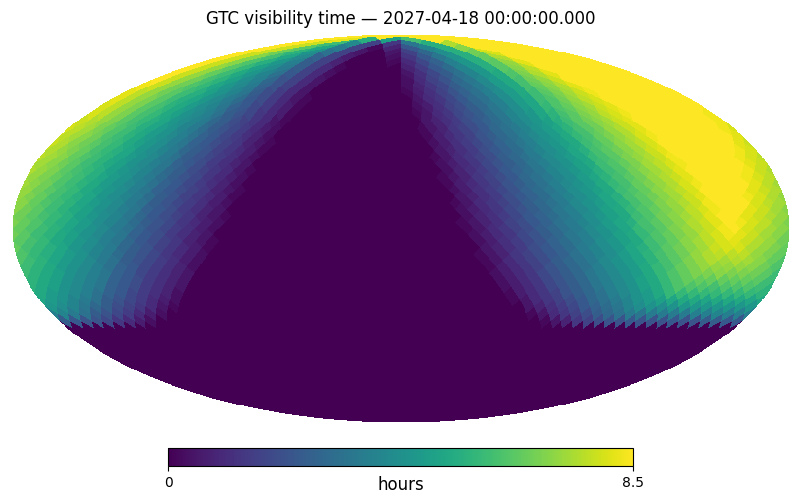

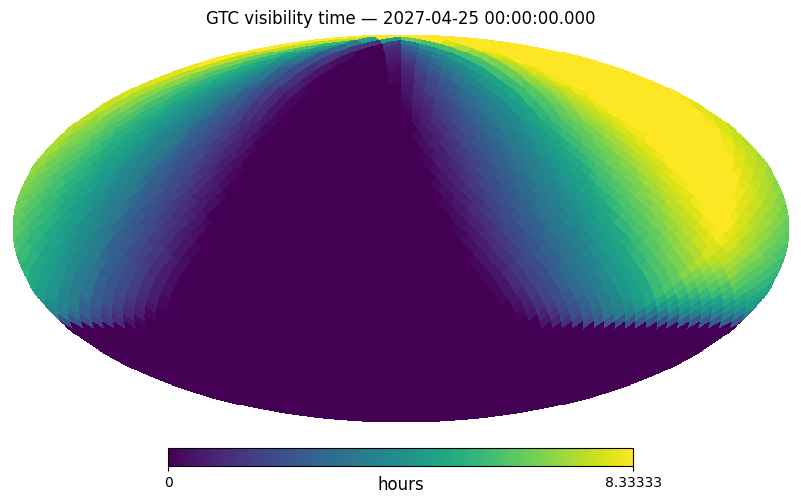

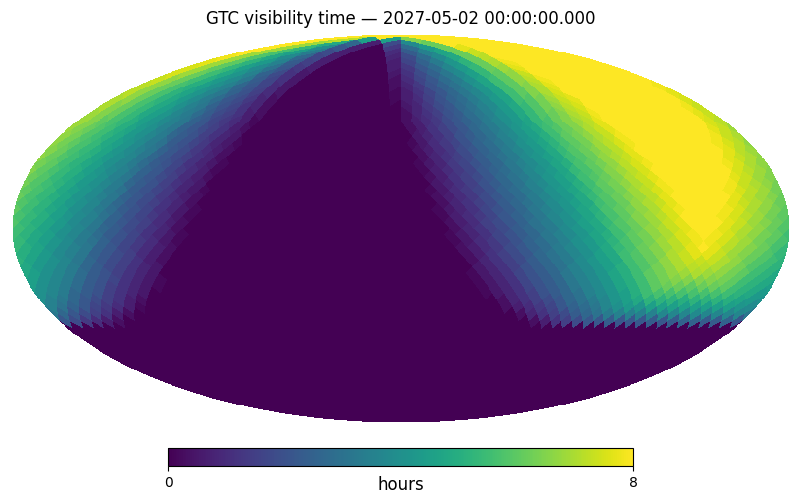

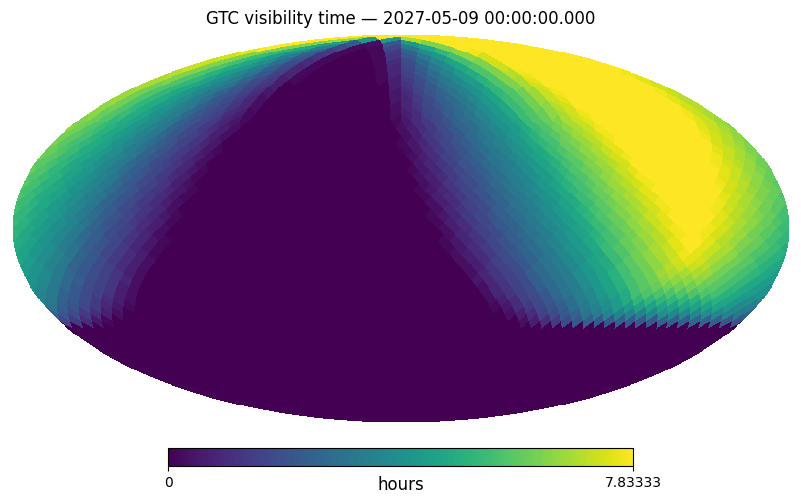

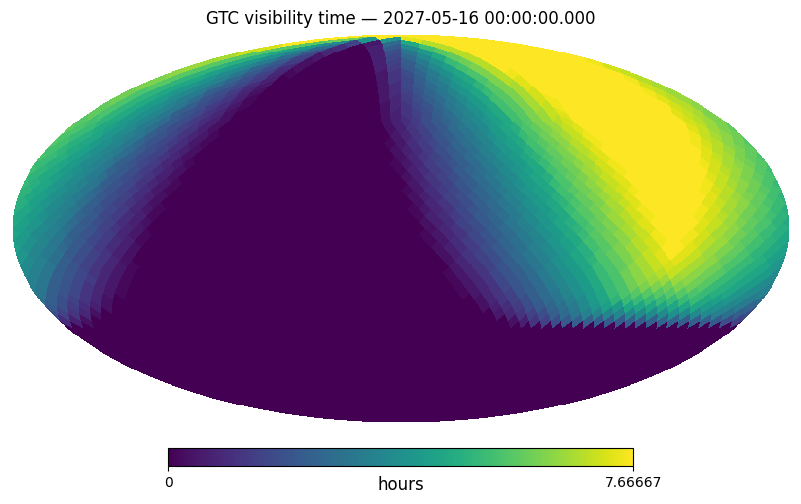

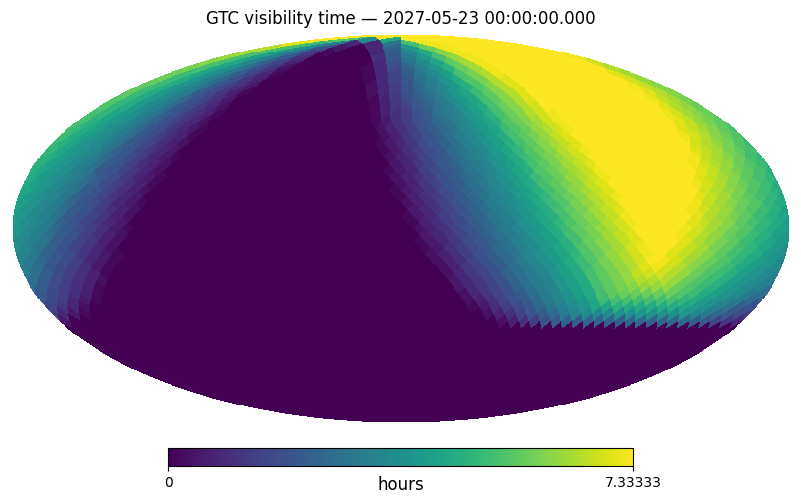

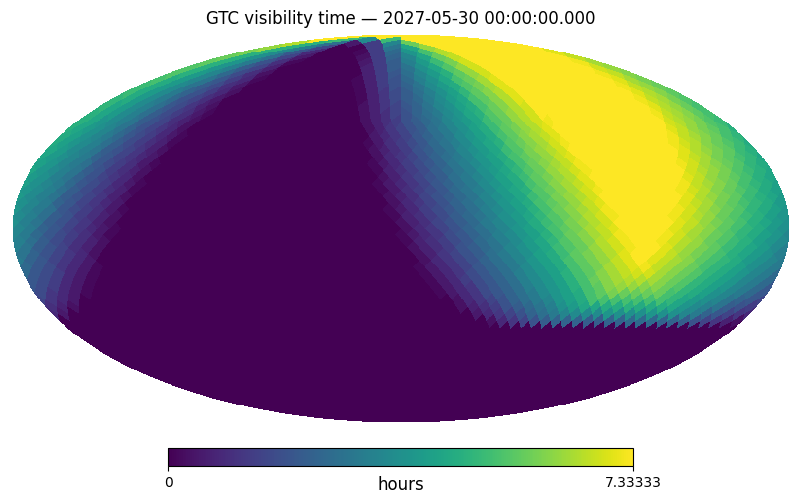

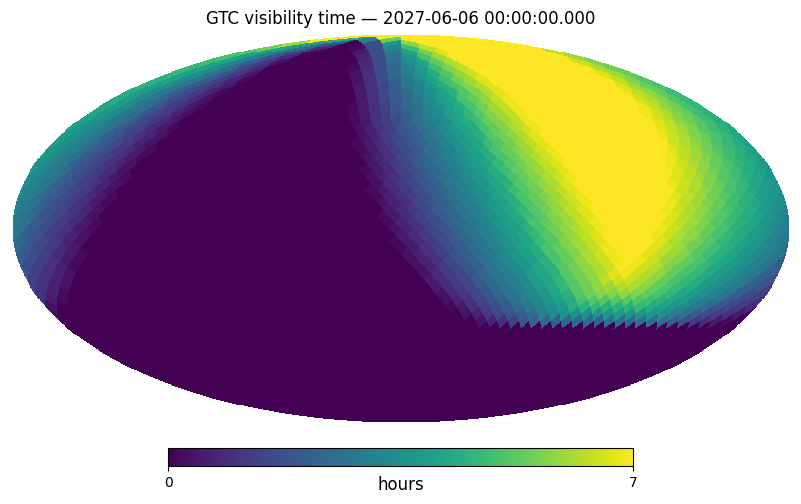

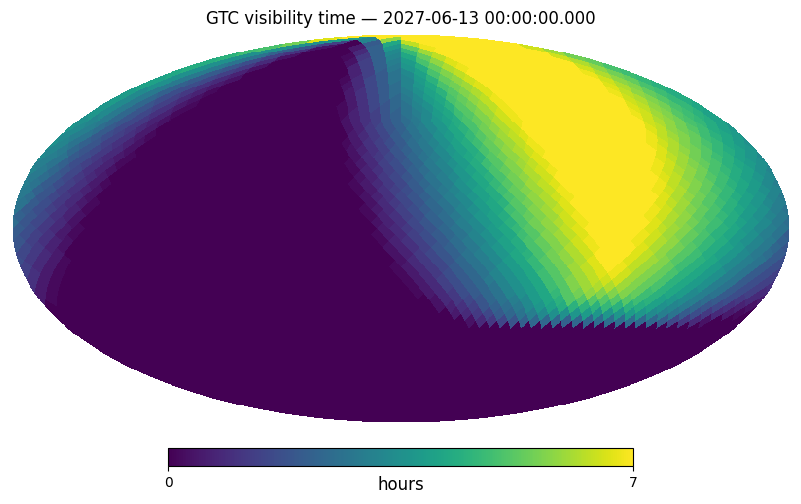

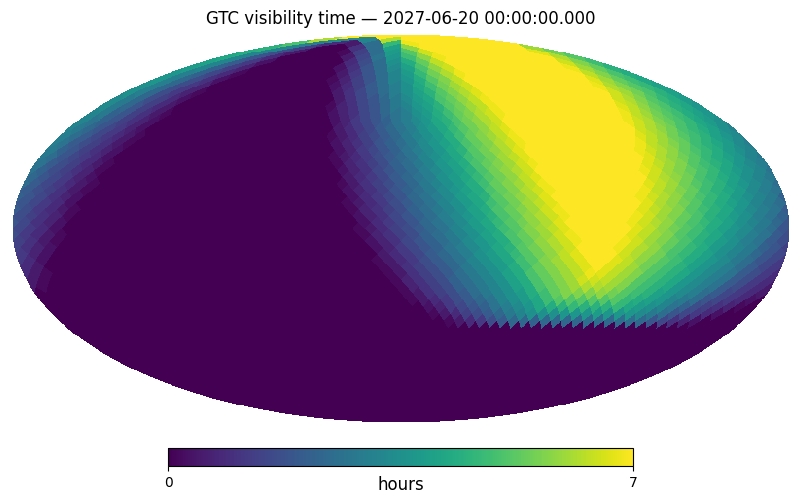

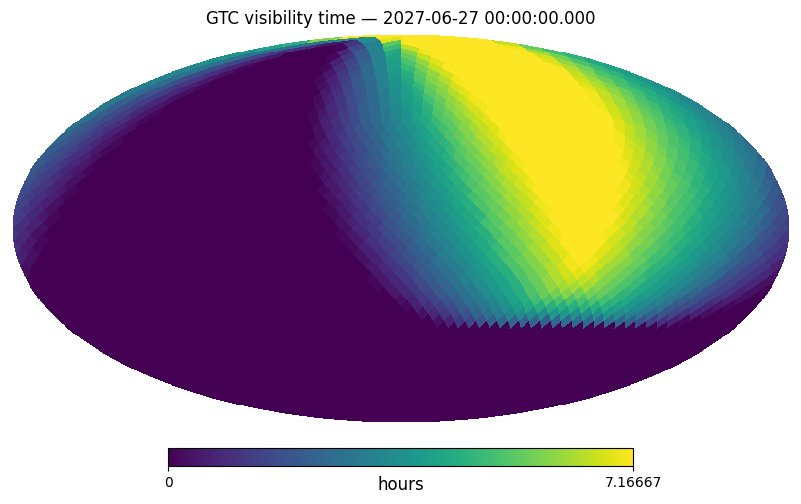

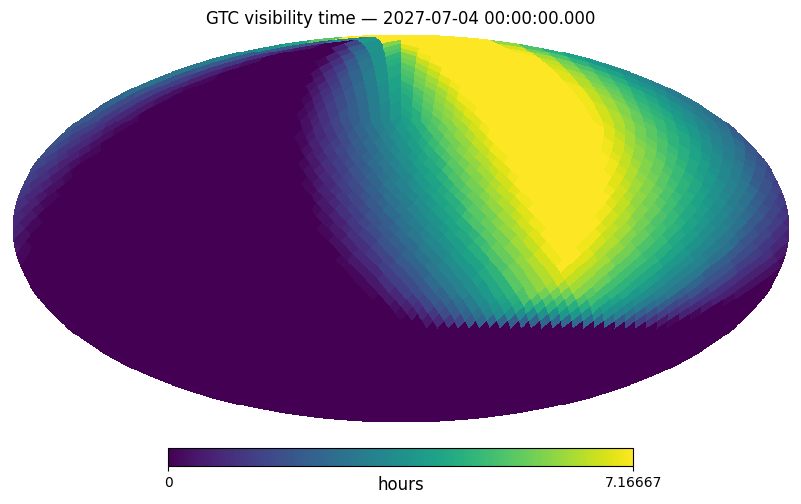

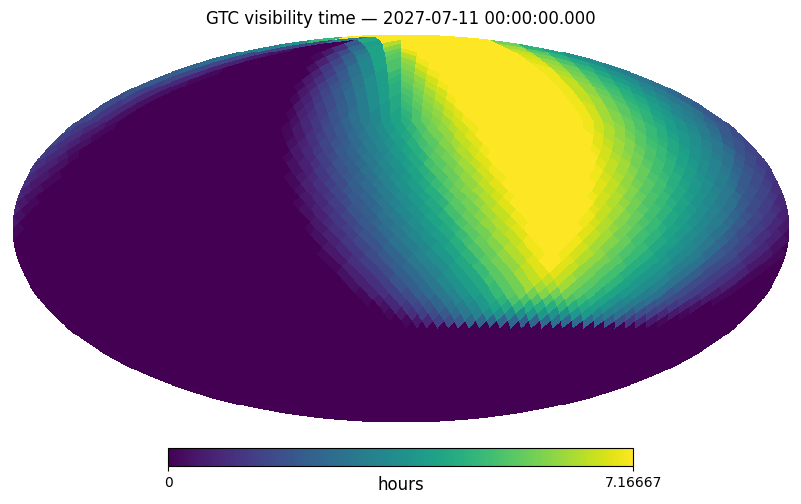

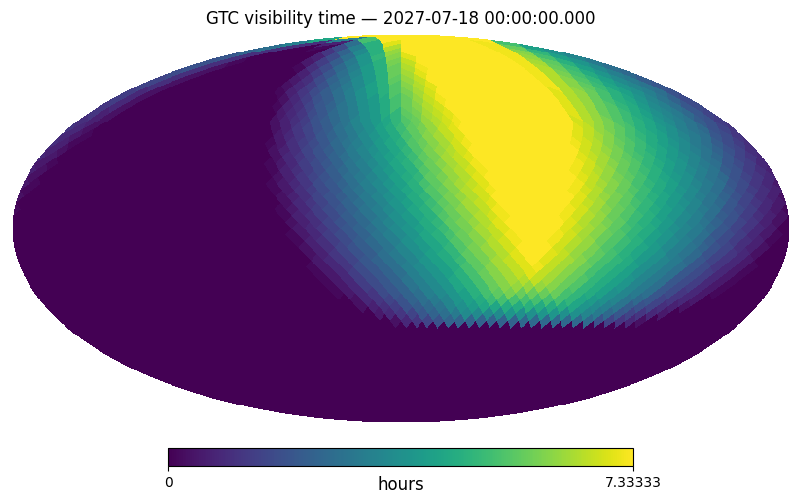

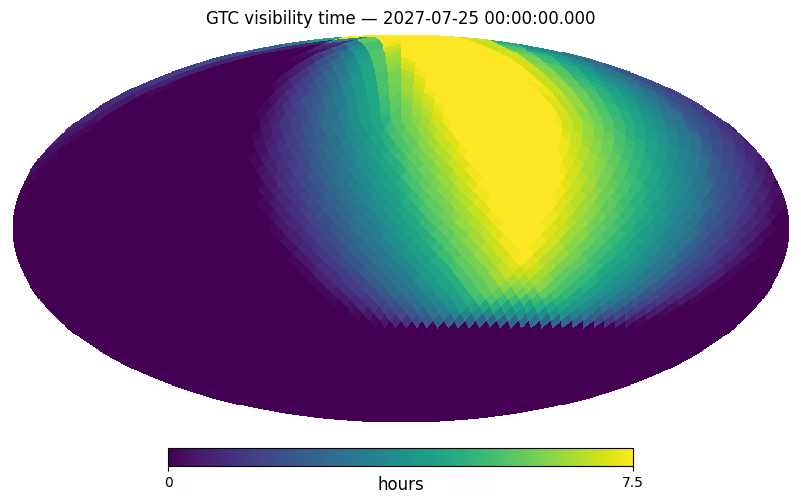

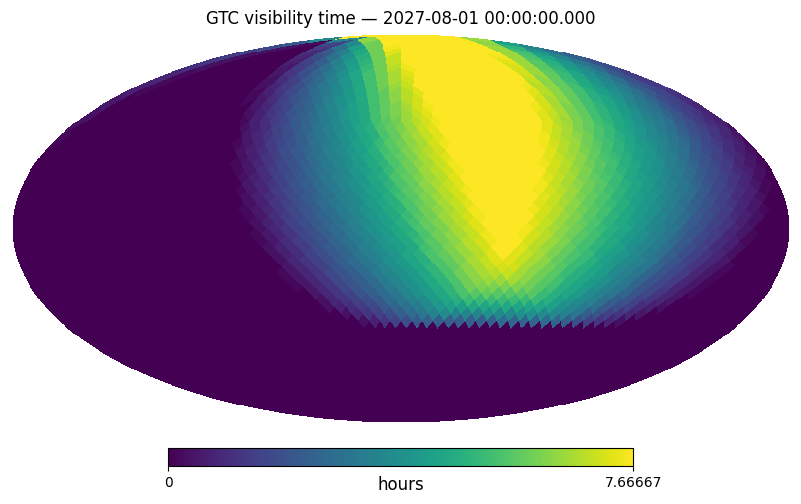

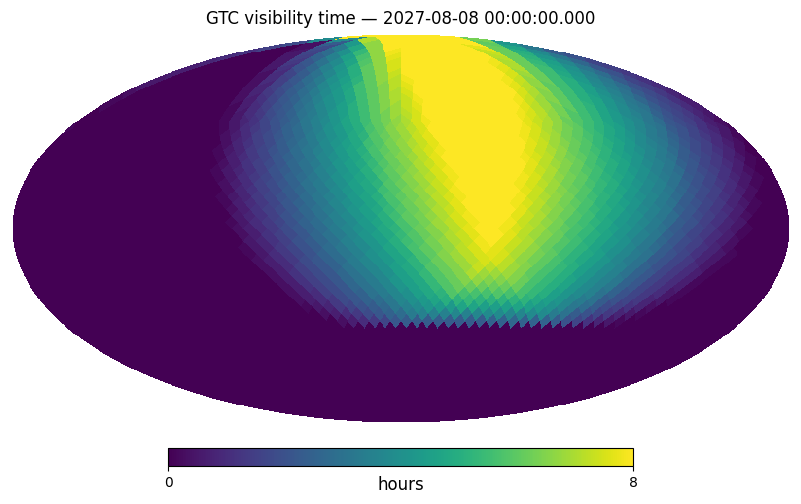

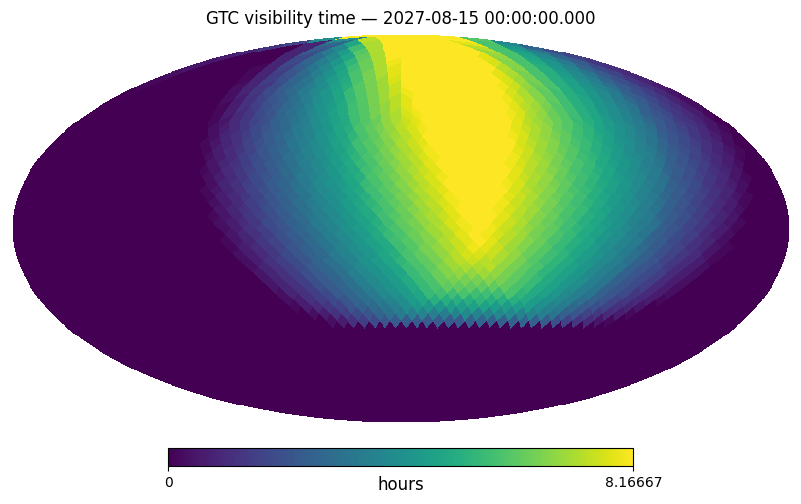

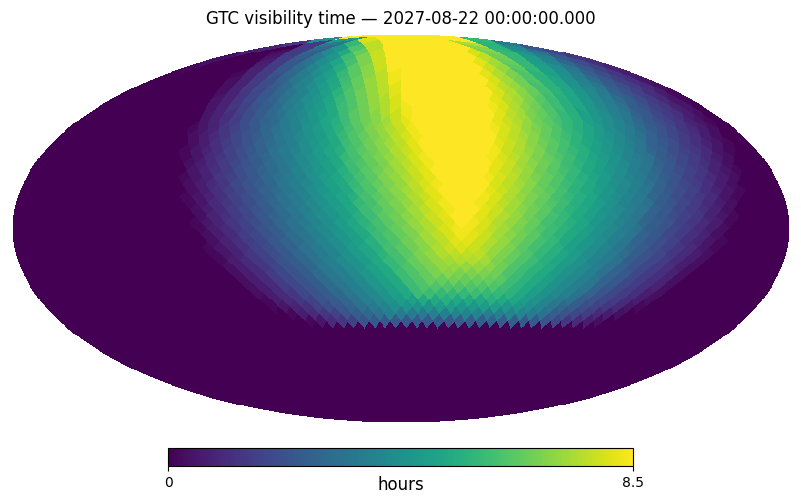

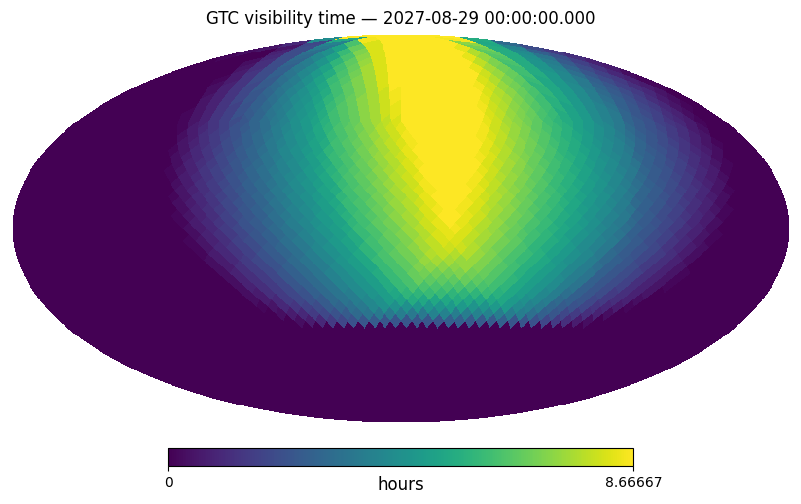

GIF saved to: assignment_outputs/gtc_one_year_visibility.gif
Frames: 53


In [10]:
import healpy as hp
import imageio.v2 as imageio
from IPython.display import Image, display

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

NSIDE = 16


weekly_dates = (
    Time("2026-08-30", scale="utc")
    + np.arange(53) * 7 * u.day
)


print("First date:", weekly_dates[0].iso)
print("Last date :", weekly_dates[-1].iso)

frame_dir = OUTPUT_DIR / "q20_frames"
frame_dir.mkdir(
    parents=True,
    exist_ok=True
)

frame_files = []


ppix = hp.nside2npix(NSIDE)

theta, phi_hp = hp.pix2ang(
    NSIDE,
    np.arange(ppix)
)
dec_hp = 90 * u.deg - theta * u.rad
ra_hp = phi_hp * u.rad

sky = SkyCoord(
    ra=ra_hp,
    dec=dec_hp,
    frame="icrs"
)

for frame_number, date in enumerate(weekly_dates):


    midnight = date


    sample_times = (
        midnight
        + np.arange(145) * 10 * u.min
    )


    visible_count = np.zeros(
        ppix,
        dtype=float
    )

    for t in sample_times:

        frame = AltAz(
            obstime=t,
            location=gtc_location,
            pressure=0 * u.hPa
        )

        sky_altaz = sky.transform_to(frame)

        altitude = (
            sky_altaz.alt.to_value(u.deg)
        )

        airmass = np.asarray(
            sky_altaz.secz,
            dtype=float
        )

        sun = get_sun(t)

        sun_altaz = sun.transform_to(frame)

        sun_altitude = (
            sun_altaz.alt.to_value(u.deg)
        )

        visible = (
            (altitude > 0)
            & np.isfinite(airmass)
            & (airmass <= 2.5)
            & (sun_altitude <= -18)
        )

        visible_count += visible


    plt.figure(figsize=(12, 6))

    hp.mollview(
        visible_count * 10 / 60,
        title=(
            "GTC visibility time — "
            + date.iso
        ),
        unit="hours",
        min=0,
        max=np.nanmax(
            visible_count * 10 / 60
        ),
        cmap="viridis",
        hold=True
    )

    frame_path = (
        frame_dir
        / f"frame_{frame_number:03d}.png"
    )

    plt.savefig(
        frame_path,
        dpi=120,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

    frame_files.append(
        frame_path
    )

gif_path = (
    OUTPUT_DIR
    / "gtc_one_year_visibility.gif"
)

images = [
    imageio.imread(path)
    for path in frame_files
]

imageio.mimsave(
    gif_path,
    images,
    duration=0.25,
    loop=0
)

print("GIF saved to:", gif_path)
print("Frames:", len(frame_files))


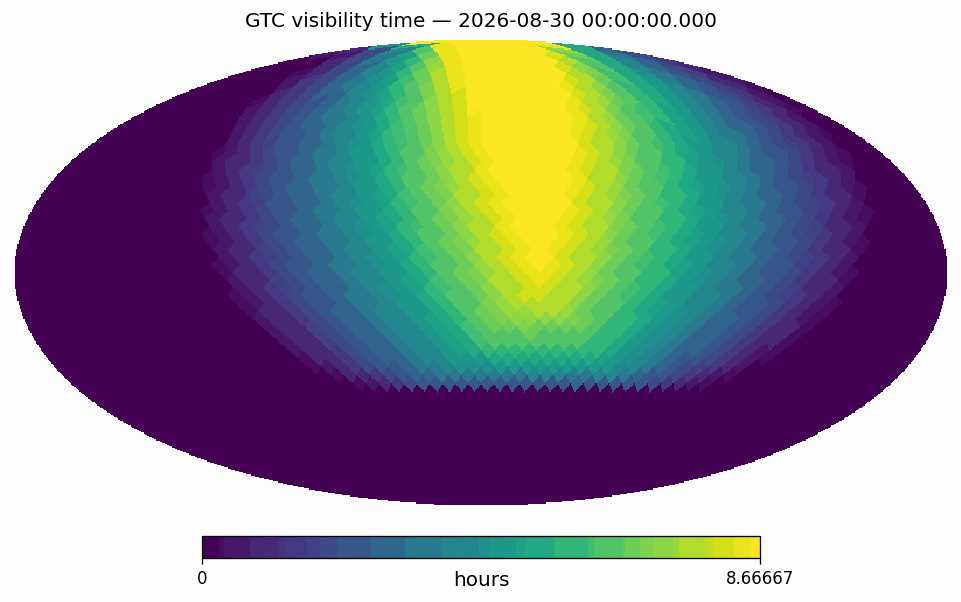

In [9]:
from IPython.display import Image, display
display(Image(gif_path))

The observable part of the sky changes throughout the year because the Sun’s apparent position changes along the ecliptic.

As a result, the time of astronomical darkness occurs at different Local Sidereal Times during different seasons.

Because the Earth rotates, celestial objects appear to move across the sky during the night. At the same time, as the Earth revolves around the Sun, the apparent position of the Sun changes. This changes the relationship between the Sun, the observer, Local Sidereal Time, and the celestial sphere.

Therefore, different regions of the sky become observable during astronomical night at different times of the year. This produces a seasonal variation in sky visibility.


![](assignment_outputs/gtc_one_year_visibility.gif)

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
